# Clasificación de sentimientos usando Regresión Logística
## Práctica 5: Clasificación de texto
---
Objetivo de la práctica: Entrenar un modelo de Regresión Logística para que aprenda a clasificar texto en 6 categorías de sentimiento, usando el dataset de Análisis de Sentimientos.
#### Ana Nicole Martínez Morales

In [1]:
# Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string
import nltk


In [3]:
from google.colab import files
from wordcloud import WordCloud
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)


In [4]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [9]:
traduccion_sentimientos = {
    'peaceful': 'Tranquilo',
    'mad': 'Enojado',
    'powerful': 'Poderoso',
    'sad': 'Triste',
    'joyful': 'Alegre',
    'scared': 'Asustado'
}

In [11]:
#uploaded = files.upload()

In [12]:
sms = pd.read_csv("sentiment_analysis_dataset.csv")

In [15]:
print("PRIMERAS FILAS DEL DATASET")
display(sms.head())

PRIMERAS FILAS DEL DATASET


,user,text,date,emotion,sentiment
0,@erreborda,termine bien abrumado después de hoy,"Jan 6, 2024 · 2:53 AM UTC",overwhelmed,scared
1,@shpiderduck,me siento abrumado,"Jan 6, 2024 · 2:35 AM UTC",overwhelmed,scared
2,@Alex_R_art,Me siento un poco abrumado por la cantidad de ...,"Jan 6, 2024 · 12:20 AM UTC",overwhelmed,scared
3,@anggelinaa97,Salvador la única persona que no la ha abrumad...,"Jan 5, 2024 · 10:38 PM UTC",overwhelmed,scared
4,@diegoreyesvqz,Denme un helado o algo que ando full abrumado.,"Jan 5, 2024 · 8:38 PM UTC",overwhelmed,scared


In [16]:
print("INFORMACIÓN DEL DATASET")
sms.info()

INFORMACIÓN DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2590 entries, 0 to 2589
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   user       2590 non-null   object
 1   text       2590 non-null   object
 2   date       2590 non-null   object
 3   emotion    2590 non-null   object
 4   sentiment  2590 non-null   object
dtypes: object(5)
memory usage: 101.3+ KB


In [17]:
print("DIMENSIONES DEL DATASET")
print("Filas y columnas:", sms.shape)

DIMENSIONES DEL DATASET
Filas y columnas: (2590, 5)


In [18]:
print("COLUMNAS")
print(sms.columns)

COLUMNAS
Index(['user', 'text', 'date', 'emotion', 'sentiment'], dtype='object')


In [19]:
print("CANTIDAD DE REGISTROS POR SENTIMIENTO")
conteo_sentimientos = sms['sentiment'].value_counts()
print(conteo_sentimientos)

CANTIDAD DE REGISTROS POR SENTIMIENTO
sentiment
peaceful    660
mad         530
powerful    420
sad         360
joyful      350
scared      270
Name: count, dtype: int64


In [20]:
print("Cantidad de registros por sentimiento en español:")
for sentimiento, cantidad in conteo_sentimientos.items():
    nombre_espanol = traduccion_sentimientos.get(
        sentimiento,
        sentimiento
    )
    print(
        f"{nombre_espanol}: {cantidad}"
    )

Cantidad de registros por sentimiento en español:
Tranquilo: 660
Enojado: 530
Poderoso: 420
Triste: 360
Alegre: 350
Asustado: 270


GRÁFICA DE DISTRIBUCIÓN DE SENTIMIENTOS


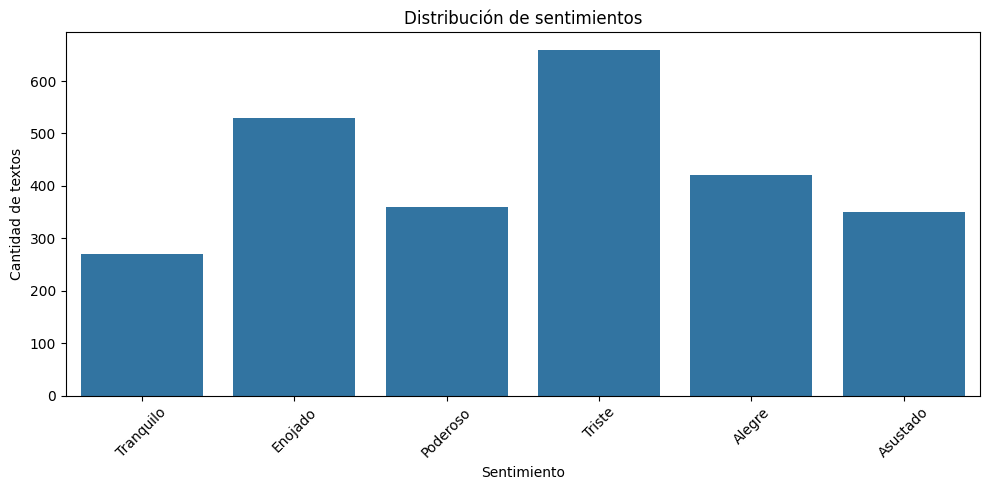

In [21]:
print("GRÁFICA DE DISTRIBUCIÓN DE SENTIMIENTOS")
plt.figure(figsize=(10, 5))
sns.countplot(
    data=sms,
    x='sentiment'
)
plt.title('Distribución de sentimientos')
plt.xlabel('Sentimiento')
plt.ylabel('Cantidad de textos')
plt.xticks(
    ticks=range(len(conteo_sentimientos.index)),
    labels=[
        traduccion_sentimientos.get(
            sentimiento,
            sentimiento
        )
        for sentimiento in conteo_sentimientos.index
    ],
    rotation=45
)
plt.tight_layout()
plt.show()

In [22]:
sms = sms[['text', 'sentiment']]

In [23]:
print("VALORES FALTANTES")
print(sms.isnull().sum())

VALORES FALTANTES
text         0
sentiment    0
dtype: int64


In [26]:
sms.dropna(
    inplace=True
)
print("Dimensiones después de eliminar valores faltantes:")
print(sms.shape)

Dimensiones después de eliminar valores faltantes:
(2590, 2)


In [28]:
print("DATOS DUPLICADOS")
print("Cantidad de registros duplicados:",sms.duplicated().sum())
sms.drop_duplicates(inplace=True)
print("Dimensiones después de eliminar duplicados:",sms.shape)

DATOS DUPLICADOS
Cantidad de registros duplicados: 0
Dimensiones después de eliminar duplicados: (2365, 2)


In [31]:
print("CREAR UNA COLUMNA CON LA LONGITUD DEL TEXTO")
sms['message_len'] = sms['text'].apply(len)
display(sms.head())

CREAR UNA COLUMNA CON LA LONGITUD DEL TEXTO


,text,sentiment,message_len
0,termine bien abrumado después de hoy,scared,36
1,me siento abrumado,scared,18
2,Me siento un poco abrumado por la cantidad de ...,scared,116
3,Salvador la única persona que no la ha abrumad...,scared,76
4,Denme un helado o algo que ando full abrumado.,scared,46


ANALIZAR LA LONGITUD DE LOS TEXTOS


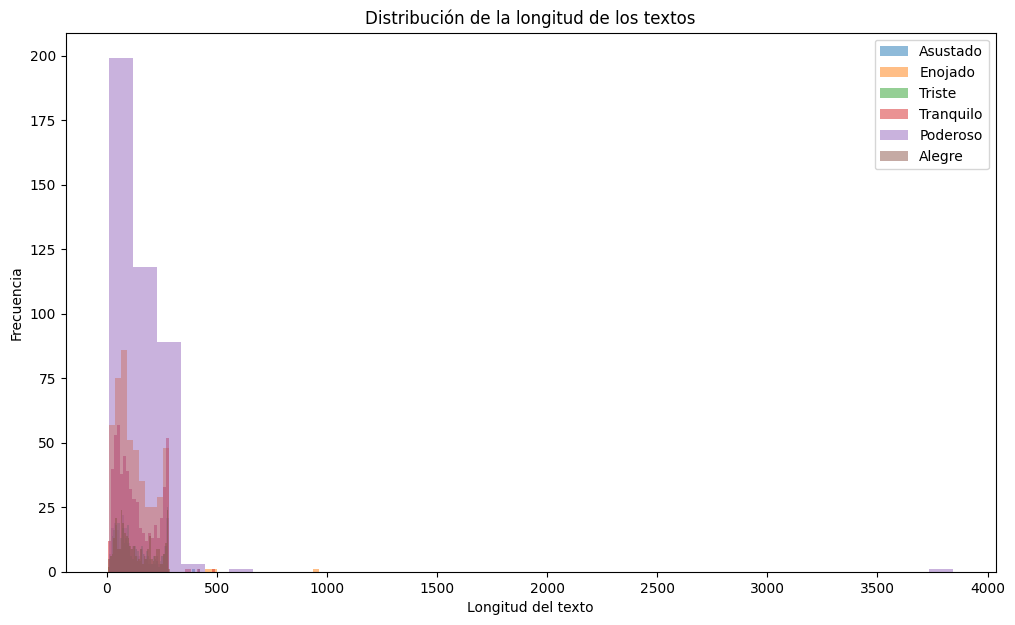

In [32]:
print("ANALIZAR LA LONGITUD DE LOS TEXTOS")
plt.figure(figsize=(12, 7))
for sentimiento in sms['sentiment'].unique():
    nombre_espanol = traduccion_sentimientos.get(
        sentimiento,
        sentimiento)
    sms[
        sms['sentiment'] == sentimiento
    ]['message_len'].plot(
        kind='hist',
        bins=35,
        alpha=0.5,
        label=nombre_espanol)

plt.legend()
plt.xlabel("Longitud del texto")
plt.ylabel("Frecuencia")
plt.title("Distribución de la longitud de los textos")
plt.show()


In [38]:
print("PREPROCESAMIENTO DEL TEXTO")
STOPWORDS_ES = set(
    stopwords.words('spanish')
)
palabras_importantes = {
    'no',
    'nunca',
    'jamás',
    'nada',
    'nadie',
    'ningún',
    'ninguna',
    'ninguno',
    'ni',
    'tampoco',
    'sin'
}
STOPWORDS_ES = STOPWORDS_ES - palabras_importantes
print("limpieza")
def text_process(mess):
    # Convertir el texto a string por seguridad
    mess = str(mess)
    # Convertir a minúsculas
    mess = mess.lower()
    # Eliminar signos de puntuación
    nopunc = [
        char
        for char in mess
        if char not in string.punctuation
    ]
    # Volver a unir los caracteres
    nopunc = ''.join(
        nopunc
    )
    # Separar el texto en palabras
    palabras = nopunc.split()
    # Eliminar únicamente las stopwords en español
    palabras_limpias = [

        palabra

        for palabra in palabras

        if palabra not in STOPWORDS_ES

    ]
    # Volver a unir las palabras
    return ' '.join(
        palabras_limpias
    )
sms['clean_text'] = sms['text'].apply(
    text_process
)

PREPROCESAMIENTO DEL TEXTO
limpieza


In [39]:
print("COMPARACIÓN ENTRE TEXTO ORIGINAL Y TEXTO LIMPIO")
display(sms[['text', 'clean_text']].head(15))

COMPARACIÓN ENTRE TEXTO ORIGINAL Y TEXTO LIMPIO


,text,clean_text
0,termine bien abrumado después de hoy,termine bien abrumado después hoy
1,me siento abrumado,siento abrumado
2,Me siento un poco abrumado por la cantidad de ...,siento abrumado cantidad cosas quiero dibujar ...
3,Salvador la única persona que no la ha abrumad...,salvador única persona no abrumado versiones❤😒...
4,Denme un helado o algo que ando full abrumado.,denme helado ando full abrumado
5,"Estoy abrumado de airdrops , de youtube y de t...",abrumado airdrops youtube imposible gestionarl...
6,"#MicroCuento: A veces, sin motivo aparente, o,...",microcuento veces sin motivo aparente bien raz...
7,"Oh, las vacaciones. Tesoros inciertos, venider...",oh vacaciones tesoros inciertos venideros prec...
8,me siento muy abrumado,siento abrumado
9,Consejo que nadie pidió: Si un día te siente...,consejo nadie pidió si día sientes abrumado tr...


NUBE DE PALABRAS


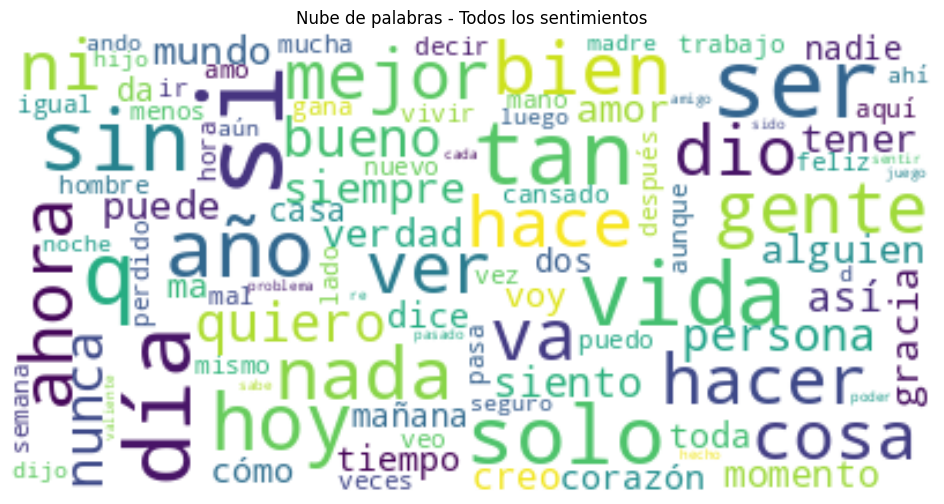

In [40]:
print("NUBE DE PALABRAS")
# Unir todos los textos limpios
word_join = ' '.join(
    sms['clean_text']
)
# Crear nube de palabras
wordscloud = WordCloud(
    max_font_size=50,
    max_words=100,
    background_color="white"
).generate(
    word_join
)
# Mostrar nube de palabras
plt.figure(figsize=(12, 6))
plt.imshow(wordscloud,interpolation="bilinear")
plt.axis("off")
plt.title("Nube de palabras - Todos los sentimientos")
plt.show()

In [41]:
print("COMPROBACIÓN DE PALABRAS DE NEGACIÓN")
print("Las siguientes palabras NO serán eliminadas:")
print(sorted(palabras_importantes))

COMPROBACIÓN DE PALABRAS DE NEGACIÓN
Las siguientes palabras NO serán eliminadas:
['jamás', 'nada', 'nadie', 'ni', 'ninguna', 'ninguno', 'ningún', 'no', 'nunca', 'sin', 'tampoco']


NUBES DE PALABRAS POR SENTIMIENTO


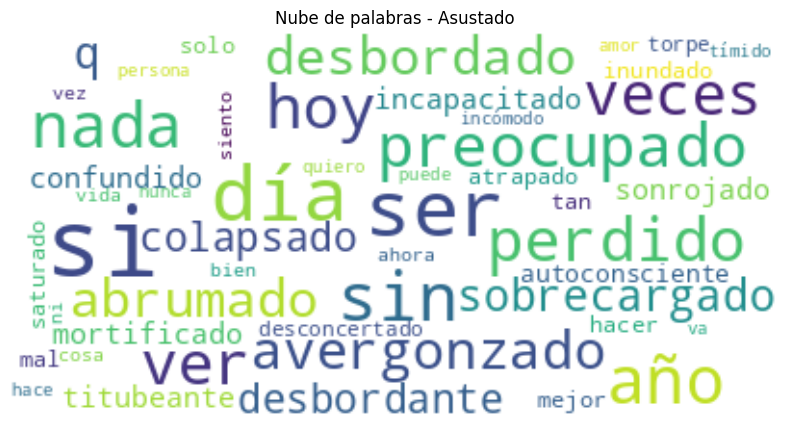

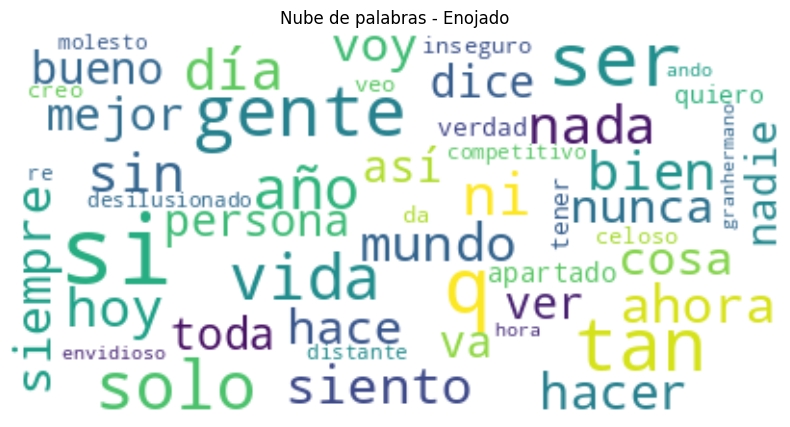

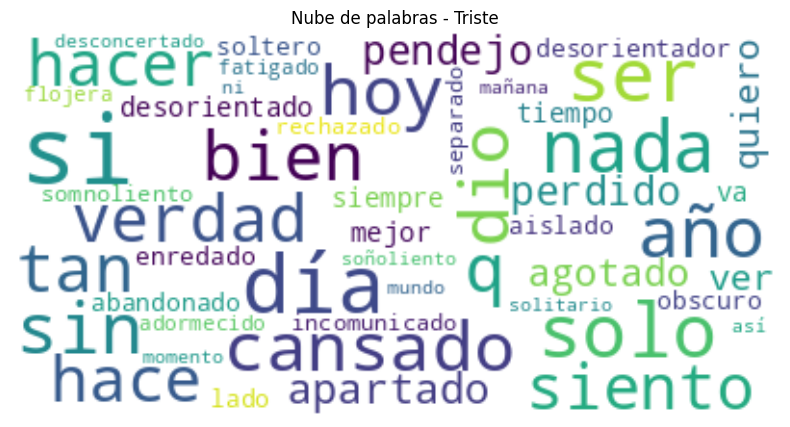

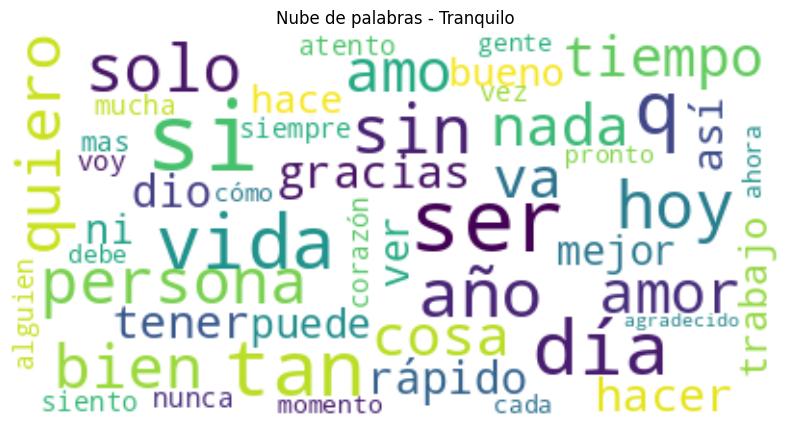

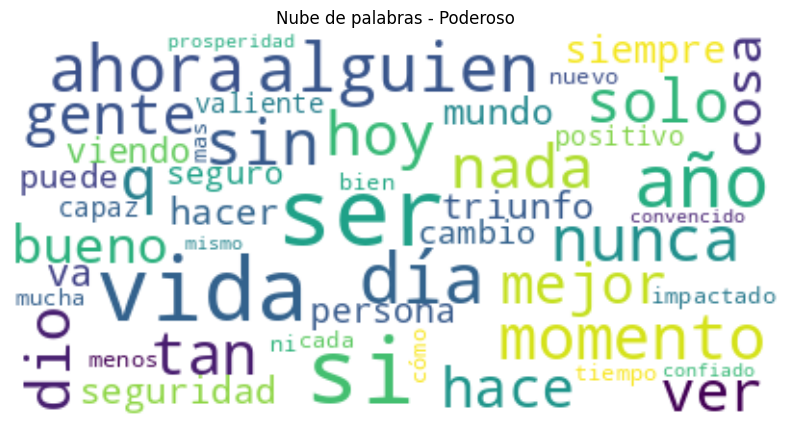

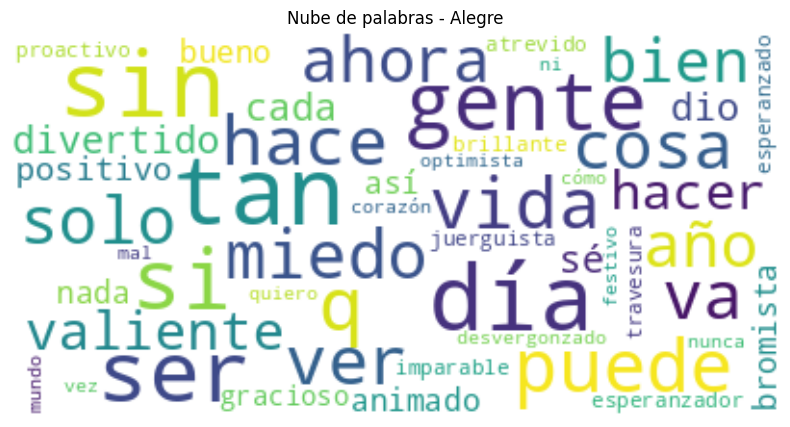

In [42]:
print("NUBES DE PALABRAS POR SENTIMIENTO")
for sentimiento in sms['sentiment'].unique():
    words = ' '.join(
        sms[
            sms['sentiment'] == sentimiento
        ]['clean_text']
    )
    # Verificar que existan palabras
    if words.strip() == "":
        continue
    wordcloud = WordCloud(
        max_font_size=50,
        max_words=50,
        background_color="white"
    ).generate(
        words
    )
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud,interpolation="bilinear")
    plt.axis("off")
    nombre_espanol = traduccion_sentimientos.get(
        sentimiento,
        sentimiento)
    plt.title(f"Nube de palabras - {nombre_espanol}")
    plt.show()

In [43]:
print("DEFINIR VARIABLES")
X = sms['clean_text']
y = sms['sentiment']

DEFINIR VARIABLES


In [44]:
print("VARIABLES")
print("Cantidad de textos:",X.shape)
print("Cantidad de etiquetas:",y.shape)

VARIABLES
Cantidad de textos: (2365,)
Cantidad de etiquetas: (2365,)


In [48]:
print("DIVIDIR LOS DATOS")
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=0,
    stratify=y)


print(
    "Datos de entrenamiento:",
    X_train.shape)
print(
    "Datos de prueba:",
    X_test.shape)
print("Porcentaje de entrenamiento:",
    len(X_train) / len(X) * 100,
    "%")
print(
    "Porcentaje de prueba:",
    len(X_test) / len(X) * 100,
    "%")

DIVIDIR LOS DATOS
Datos de entrenamiento: (1655,)
Datos de prueba: (710,)
Porcentaje de entrenamiento: 69.97885835095138 %
Porcentaje de prueba: 30.021141649048626 %


In [49]:
print("CONVERTIR TEXTO A NÚMEROS CON COUNTVECTORIZER")
vect = CountVectorizer()
vect.fit(X_train)
X_train_dtm = vect.transform(X_train)

print("COUNTVECTORIZER")
print("Tipo de datos:")
print(type(X_train_dtm))
print("Dimensiones de la matriz de entrenamiento:")
print(X_train_dtm.shape)

# Mostrar cantidad de palabras del vocabulario
print("Cantidad de palabras del vocabulario:")
print(len(vect.vocabulary_))


CONVERTIR TEXTO A NÚMEROS CON COUNTVECTORIZER
COUNTVECTORIZER
Tipo de datos:
<class 'scipy.sparse._csr.csr_matrix'>
Dimensiones de la matriz de entrenamiento:
(1655, 8183)
Cantidad de palabras del vocabulario:
8183


In [50]:
print("TRANSFORMAR LOS DATOS DE PRUEBA")
X_test_dtm = vect.transform(X_test)
print("MATRIZ DE PRUEBA")
print("Dimensiones de la matriz de prueba:")
print(X_test_dtm.shape)

TRANSFORMAR LOS DATOS DE PRUEBA
MATRIZ DE PRUEBA
Dimensiones de la matriz de prueba:
(710, 8183)


In [52]:
print("TRANSFORMACIÓN TF-IDF")
tfidf_transformer = TfidfTransformer()
tfidf_transformer.fit(X_train_dtm)
X_train_tfidf = tfidf_transformer.transform(X_train_dtm)
X_test_tfidf = tfidf_transformer.transform(X_test_dtm)
print("Dimensiones TF-IDF entrenamiento:")
print(X_train_tfidf.shape)
print("Dimensiones TF-IDF prueba:")
print(X_test_tfidf.shape)

TRANSFORMACIÓN TF-IDF
Dimensiones TF-IDF entrenamiento:
(1655, 8183)
Dimensiones TF-IDF prueba:
(710, 8183)


In [53]:
print("MODELO DE REGRESIÓN LOGÍSTICA")
modelo = LogisticRegression(max_iter=1000,random_state=0)

MODELO DE REGRESIÓN LOGÍSTICA


In [54]:
print("ENTRENAR EL MODELO")
modelo.fit(X_train_tfidf,y_train)
print("Modelo entrenado correctamente.")

print("Clases aprendidas por el modelo:")
print(modelo.classes_)
print("Clases en español:")
for clase in modelo.classes_:
    print(f"{clase} -> {traduccion_sentimientos.get(clase, clase)}")

ENTRENAR EL MODELO
Modelo entrenado correctamente.
Clases aprendidas por el modelo:
['joyful' 'mad' 'peaceful' 'powerful' 'sad' 'scared']
Clases en español:
joyful -> Alegre
mad -> Enojado
peaceful -> Tranquilo
powerful -> Poderoso
sad -> Triste
scared -> Asustado


In [55]:
print("REALIZAR PREDICCIONES")
y_pred = modelo.predict(X_test_tfidf)
print("PRIMERAS PREDICCIONES")
print(y_pred[:20])
print("Primeras predicciones en español:")
for prediccion in y_pred[:20]:
    print(
        traduccion_sentimientos.get(
            prediccion,
            prediccion))

REALIZAR PREDICCIONES
PRIMERAS PREDICCIONES
['mad' 'scared' 'mad' 'peaceful' 'peaceful' 'sad' 'peaceful' 'powerful'
 'joyful' 'peaceful' 'peaceful' 'peaceful' 'joyful' 'sad' 'joyful' 'mad'
 'peaceful' 'peaceful' 'peaceful' 'mad']
Primeras predicciones en español:
Enojado
Asustado
Enojado
Tranquilo
Tranquilo
Triste
Tranquilo
Poderoso
Alegre
Tranquilo
Tranquilo
Tranquilo
Alegre
Triste
Alegre
Enojado
Tranquilo
Tranquilo
Tranquilo
Enojado


In [57]:
print("COMPARAR PREDICCIÓN CONTRA VALOR REAL")
resultados = pd.DataFrame({
    'Texto': X_test.values,
    'Real': y_test.values,
    'Real (Español)': [
        traduccion_sentimientos.get(valor,valor)
        for valor in y_test.values],
    'Predicción': y_pred,
    'Predicción (Español)': [
        traduccion_sentimientos.get(valor,valor)
        for valor in y_pred]
})

COMPARAR PREDICCIÓN CONTRA VALOR REAL


In [58]:
print("COMPARACIÓN ENTRE SENTIMIENTO REAL Y PREDICHO")
display(resultados.head(20))

COMPARACIÓN ENTRE SENTIMIENTO REAL Y PREDICHO


,Texto,Real,Real (Español),Predicción,Predicción (Español)
0,así práctica inaccesible encontrar veredicto e...,mad,Enojado,mad,Enojado
1,no q q quieres confundido,scared,Asustado,scared,Asustado
2,solo mago incomprendido,mad,Enojado,mad,Enojado
3,🎵🎶🎵🎶 mundo entero quiero dar mensaje paz menos...,joyful,Alegre,peaceful,Tranquilo
4,preguntenle futbol dt favor no quiero saber na...,scared,Asustado,peaceful,Tranquilo
5,solo libertad comunidad venden idea individuo ...,mad,Enojado,sad,Triste
6,moscúmano mano amor❤️,peaceful,Tranquilo,peaceful,Tranquilo
7,consecuencias viene haciendo 2002 ahora defaul...,scared,Asustado,powerful,Poderoso
8,luego travesura viene arrepentimiento,joyful,Alegre,joyful,Alegre
9,acabo ver niño garza no voy hacer spoilers vi ...,peaceful,Tranquilo,peaceful,Tranquilo


In [59]:
print("CALCULAR ACCURACY")
accuracy = accuracy_score(
    y_test,
    y_pred
)
print("ACCURACY DEL MODELO")
print("Accuracy:",accuracy)
print("Accuracy (%):", accuracy * 100,"%")

CALCULAR ACCURACY
ACCURACY DEL MODELO
Accuracy: 0.5774647887323944
Accuracy (%): 57.74647887323944 %


In [60]:
print("CLASSIFICATION REPORT")
print(classification_report(
        y_test,
        y_pred,
        target_names=[
            traduccion_sentimientos.get(
                clase,
                clase
            )
            for clase in modelo.classes_
        ]
    )
)

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Alegre       0.67      0.35      0.46        98
     Enojado       0.59      0.74      0.66       145
   Tranquilo       0.49      0.86      0.63       175
    Poderoso       0.72      0.56      0.63       124
      Triste       0.65      0.36      0.47        99
    Asustado       0.62      0.19      0.29        69

    accuracy                           0.58       710
   macro avg       0.62      0.51      0.52       710
weighted avg       0.61      0.58      0.55       710



MATRIZ DE CONFUSIÓN
[[ 34  20  39   5   0   0]
 [  2 107  19   1   9   7]
 [  3   6 151  12   3   0]
 [ 11  11  30  69   3   0]
 [  1  20  38   3  36   1]
 [  0  17  29   6   4  13]]


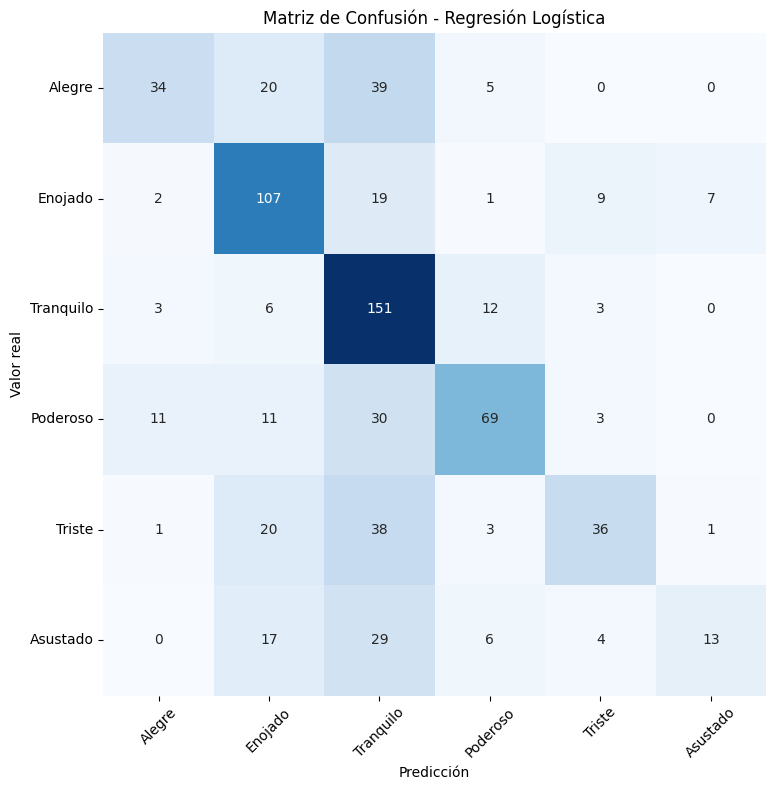

In [62]:
print("MATRIZ DE CONFUSIÓN")
matriz = confusion_matrix(
    y_test,
    y_pred,
    labels=modelo.classes_)
print(matriz)

labels_espanol = [
    traduccion_sentimientos.get(clase,clase)
    for clase in modelo.classes_]
plt.figure(figsize=(10, 8))
sns.heatmap(
    matriz,
    square=True,
    annot=True,
    fmt='d',
    cbar=False,
    cmap='Blues',
    xticklabels=labels_espanol,
    yticklabels=labels_espanol)
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.title('Matriz de Confusión - Regresión Logística')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [63]:
print("PROBAR EL MODELO CON UN TEXTO NUEVO")
nuevo_texto = ["Me siento increíblemente feliz hoy"]
print("Texto:",nuevo_texto[0])

PROBAR EL MODELO CON UN TEXTO NUEVO
Texto: Me siento increíblemente feliz hoy


In [64]:
print("LIMPIAR EL NUEVO TEXTO")
nuevo_texto_limpio = [text_process(texto)for texto in nuevo_texto]
print("Texto limpio:")
print(nuevo_texto_limpio[0])

LIMPIAR EL NUEVO TEXTO
Texto limpio:
siento increíblemente feliz hoy


In [65]:
print("VECTORIZAR EL TEXTO NUEVO")
nuevo_dtm = vect.transform(nuevo_texto_limpio)
nuevo_tfidf = tfidf_transformer.transform(nuevo_dtm)

VECTORIZAR EL TEXTO NUEVO


In [66]:
print("HACER LA PREDICCIÓN")
prediccion = modelo.predict(nuevo_tfidf)
print("Texto:",nuevo_texto[0])
print("Sentimiento predicho:",prediccion[0])

prediccion_espanol = traduccion_sentimientos.get(prediccion[0],prediccion[0])
print("Sentimiento predicho en español:",prediccion_espanol)

HACER LA PREDICCIÓN
Texto: Me siento increíblemente feliz hoy
Sentimiento predicho: peaceful
Sentimiento predicho en español: Tranquilo


In [68]:
print("OBTENER PROBABILIDADES")
probabilidades = modelo.predict_proba(
    nuevo_tfidf)
resultado_prob = pd.DataFrame(
    probabilidades,
    columns=modelo.classes_)
resultado_prob.columns = [    traduccion_sentimientos.get(columna,columna)
    for columna in resultado_prob.columns]
display(resultado_prob)

OBTENER PROBABILIDADES


,Alegre,Enojado,Tranquilo,Poderoso,Triste,Asustado
0,0.075766,0.145776,0.282527,0.201916,0.137845,0.15617


In [69]:
print("PROBABILIDADES ORDENADAS")
probabilidades_ordenadas = (
    resultado_prob
    .T
    .sort_values(
        by=0,
        ascending=False))
probabilidades_ordenadas.columns = ['Probabilidad']
probabilidades_ordenadas['Probabilidad (%)'] = (probabilidades_ordenadas['Probabilidad']* 100)
display(probabilidades_ordenadas)


PROBABILIDADES ORDENADAS


,Probabilidad,Probabilidad (%)
Tranquilo,0.282527,28.252681
Poderoso,0.201916,20.191621
Asustado,0.156170,15.616985
Enojado,0.145776,14.577631
Triste,0.137845,13.784450
Alegre,0.075766,7.576632


In [70]:
print("RESULTADO FINAL")
print("Texto analizado:",nuevo_texto[0])
print("Sentimiento:",prediccion_espanol)
print("Confianza aproximada:",round(probabilidades.max() * 100,2),"%")

RESULTADO FINAL
Texto analizado: Me siento increíblemente feliz hoy
Sentimiento: Tranquilo
Confianza aproximada: 28.25 %
